# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [1]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# DO NOT CHANGE

import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [3]:
bandit0 = BanditProblem(0)

In [4]:
bandit0.get_num_arms()

3

In [5]:
bandit0.get_reward(arm=0)

1.8255111545554434

In [6]:
# YOUR CHANGES HERE

bandit0 = BanditProblem(0)

print("Number of arms:", bandit0.get_num_arms())


num_samples = 1000

rewards = {}

for arm in range(bandit0.get_num_arms()):
    rewards[arm] = [
        bandit0.get_reward(arm)
        for _ in range(num_samples)
    ]

# Look at summary statistics
for arm in range(bandit0.get_num_arms()):
    print(f"Arm {arm}")
    print(f"  Min:  {np.min(rewards[arm]):.4f}")
    print(f"  Mean: {np.mean(rewards[arm]):.4f}")
    print(f"  Max:  {np.max(rewards[arm]):.4f}")

Number of arms: 3
Arm 0
  Min:  0.0000
  Mean: 0.8149
  Max:  4.0662
Arm 1
  Min:  0.0000
  Mean: 0.5735
  Max:  4.4076
Arm 2
  Min:  0.0000
  Mean: 0.9262
  Max:  4.8858


In [7]:
%pip install matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


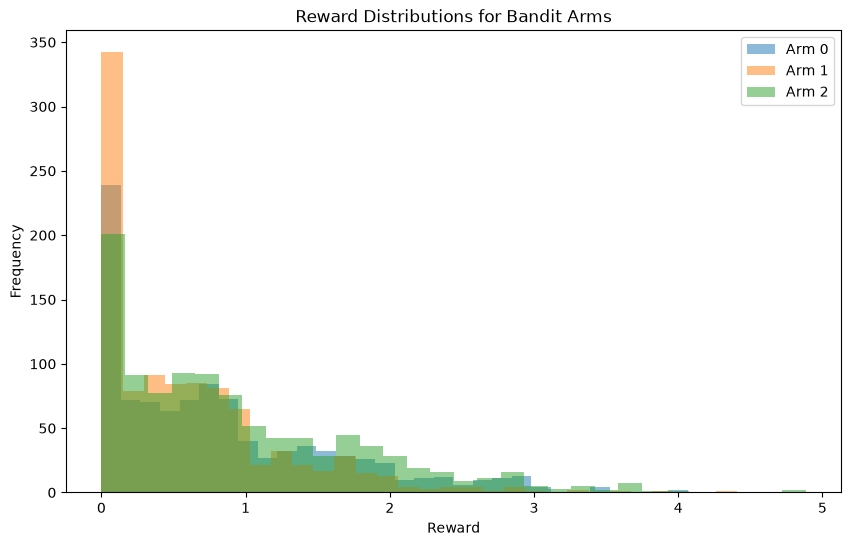

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for arm in range(bandit0.get_num_arms()):
    plt.hist(
        rewards[arm],
        bins=30,
        alpha=0.5,
        label=f"Arm {arm}"
    )

plt.xlabel("Reward")
plt.ylabel("Frequency")
plt.title("Reward Distributions for Bandit Arms")
plt.legend()
plt.show()

In [9]:
algorithm_choice = """UCB: I chose the Upper Confidence Bound algorithm because the observed rewards are continuous numerical values rather than binary outcomes, so Bernoulli-based bandit algorithms are not appropriate."""

with open("algorithm-choice.txt", "w") as file:
    file.write(algorithm_choice)

print("algorithm-choice.txt saved successfully!")

algorithm-choice.txt saved successfully!


In [10]:
with open("algorithm-choice.txt", "r") as file:
    print(file.read())

UCB: I chose the Upper Confidence Bound algorithm because the observed rewards are continuous numerical values rather than binary outcomes, so Bernoulli-based bandit algorithms are not appropriate.


Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week.
Write a file "algorithm-choice.txt" that states your choice and give a single sentence justifying your choice and rejecting the alternatives.
Keep your explanation concise; you should be able to justify your choice solely based on the type of numbers observed, and whether those match the bandit algorithms that you have learned.

## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2026.

In [11]:
# YOUR CHANGES HERE

bandit = BanditProblem(2026)

num_arms = bandit.get_num_arms()
num_actions = 1000

print("Number of arms:", num_arms)

Number of arms: 3


Write a file "history.tsv" with columns action and reward in the order that the actions were taken.

In [12]:
# YOUR CHANGES HERE
# Track how many times each arm has been selected
counts = np.zeros(num_arms)

# Track the estimated mean reward for each arm
values = np.zeros(num_arms)

# Store action and reward history
actions = []
rewards_history = []

for t in range(num_actions):

    # Pull every arm once before calculating UCB
    if t < num_arms:
        action = t

    else:
        ucb_values = values + np.sqrt(
            2 * np.log(t + 1) / counts
        )

        action = np.argmax(ucb_values)

    # Get reward from selected arm
    reward = bandit.get_reward(action)

    # Save history
    actions.append(action)
    rewards_history.append(reward)

    # Update count
    counts[action] += 1

    # Update estimated mean reward
    values[action] += (
        reward - values[action]
    ) / counts[action]

print("Total actions:", len(actions))
print("Arm counts:", counts)
print("Estimated mean rewards:", values)

import pandas as pd

history = pd.DataFrame({
    "action": actions,
    "reward": rewards_history
})

history.head(10)

print("Shape:", history.shape)
print("Columns:", history.columns.tolist())

history.to_csv(
    "history.tsv",
    sep="\t",
    index=False
)

print("history.tsv saved successfully!")

history_check = pd.read_csv(
    "history.tsv",
    sep="\t"
)

print(history_check.head())
print("\nShape:", history_check.shape)
print("Columns:", history_check.columns.tolist())
print("\nActions per arm:")
print(history_check["action"].value_counts().sort_index())

Total actions: 1000
Arm counts: [979.  11.  10.]
Estimated mean rewards: [1.21682864 0.16606783 0.12567672]
Shape: (1000, 2)
Columns: ['action', 'reward']
history.tsv saved successfully!
   action    reward
0       0  3.162073
1       1  0.177353
2       2  0.298303
3       0  2.759550
4       0  1.505464

Shape: (1000, 2)
Columns: ['action', 'reward']

Actions per arm:
action
0    979
1     11
2     10
Name: count, dtype: int64


In [13]:
history = pd.DataFrame({
    "action": actions,
    "reward": rewards_history
})

history.to_csv("history.tsv", sep="\t", index=False)

Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [14]:
# YOUR CHANGES HERE
actions_stats = (
    history.groupby("action")["reward"]
    .agg(
        min_reward="min",
        mean_reward="mean",
        max_reward="max"
    )
    .reset_index()
)

actions_stats


,action,min_reward,mean_reward,max_reward
0,0,0.0,1.216829,6.564312
1,1,0.0,0.166068,0.623193
2,2,0.0,0.125677,0.958464


In [15]:
print(actions_stats)

print("\nShape:", actions_stats.shape)
print("Columns:", actions_stats.columns.tolist())

   action  min_reward  mean_reward  max_reward
0       0         0.0     1.216829    6.564312
1       1         0.0     0.166068    0.623193
2       2         0.0     0.125677    0.958464

Shape: (3, 4)
Columns: ['action', 'min_reward', 'mean_reward', 'max_reward']


In [16]:
actions_stats.to_csv(
    "actions.tsv",
    sep="\t",
    index=False
)

print("actions.tsv saved successfully!")

actions.tsv saved successfully!


In [17]:
actions_check = pd.read_csv(
    "actions.tsv",
    sep="\t"
)

print(actions_check)

print("\nShape:", actions_check.shape)
print("Columns:", actions_check.columns.tolist())

   action  min_reward  mean_reward  max_reward
0       0         0.0     1.216829    6.564312
1       1         0.0     0.166068    0.623193
2       2         0.0     0.125677    0.958464

Shape: (3, 4)
Columns: ['action', 'min_reward', 'mean_reward', 'max_reward']


In [18]:
actions_stats = (
    history.groupby("action")["reward"]
    .agg(
        min_reward="min",
        mean_reward="mean",
        max_reward="max"
    )
    .reset_index()
)

actions_stats.to_csv("actions.tsv", sep="\t", index=False)

Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Estimate the regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

These estimates should be based on your previous action statistics; you should not use the true action values from the bandit code.

In [19]:
# YOUR CHANGES HERE
mean_rewards = actions_stats.set_index("action")["mean_reward"]

print("Estimated mean rewards:")
print(mean_rewards)

best_mean_reward = mean_rewards.max()

print("Best estimated mean reward:", best_mean_reward)

num_actions = 1000

# Best possible estimated total reward
best_total_reward = best_mean_reward * num_actions

strategy_results = []

# Uniform strategy
uniform_mean_reward = mean_rewards.mean()
uniform_regret = (
    best_total_reward
    - uniform_mean_reward * num_actions
)

strategy_results.append({
    "strategy": "uniform",
    "regret": uniform_regret
})

# Always choose one specific arm
for arm in mean_rewards.index:

    arm_total_reward = mean_rewards.loc[arm] * num_actions

    arm_regret = (
        best_total_reward
        - arm_total_reward
    )

    strategy_results.append({
        "strategy": f"just-{arm}",
        "regret": arm_regret
    })

# Actual strategy from Part 2
actual_estimated_reward = history["action"].map(
    mean_rewards
).sum()

actual_regret = (
    best_total_reward
    - actual_estimated_reward
)

strategy_results.append({
    "strategy": "actual",
    "regret": actual_regret
})
strategies = pd.DataFrame(strategy_results)

strategies

print(strategies)

print("\nShape:", strategies.shape)
print("Columns:", strategies.columns.tolist())



Estimated mean rewards:
action
0    1.216829
1    0.166068
2    0.125677
Name: mean_reward, dtype: float64
Best estimated mean reward: 1.216828640221952
  strategy       regret
0  uniform   713.970910
1   just-0     0.000000
2   just-1  1050.760808
3   just-2  1091.151923
4   actual    22.469888

Shape: (5, 2)
Columns: ['strategy', 'regret']


Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [20]:
# YOUR CHANGES HERE

strategies.to_csv(
    "strategies.tsv",
    sep="\t",
    index=False
)

print("strategies.tsv saved successfully!")

strategies.tsv saved successfully!


Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

In [21]:
acknowledgment_text = """I used Python libraries including NumPy, pandas, and matplotlib for the bandit analysis and visualization. I used ChatGPT to help clarify the project instructions, develop and troubleshoot Python code, and review the required output formats. I reviewed and executed the calculations in my Jupyter Notebook.


"""

with open("acknowledgments.txt", "w") as file:
    file.write(acknowledgment_text)

print("acknowledgments.txt saved successfully!")

acknowledgments.txt saved successfully!


## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.

In [22]:
import os

required_files = [
    "algorithm-choice.txt",
    "history.tsv",
    "actions.tsv",
    "strategies.tsv",
    "acknowledgments.txt"
]

print("FINAL PROJECT FILE CHECK")
print("-" * 35)

for file in required_files:
    if os.path.exists(file):
        print(f"{file}: ✓")
    else:
        print(f"{file}: MISSING")

FINAL PROJECT FILE CHECK
-----------------------------------
algorithm-choice.txt: ✓
history.tsv: ✓
actions.tsv: ✓
strategies.tsv: ✓
acknowledgments.txt: ✓
